In [29]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u

SED_KEV_TO_ERG = u.keV.to(u.erg)
KEV_TO_MEV = u.keV.to(u.MeV)
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline

In [30]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from cosipy.event_selection import GoodTimeInterval
from agn_cosi_fit_utils import draw_energy_hist_mev, open_spacecraft_history, scale_spacecraft_livetime

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
source_coord = SkyCoord(l=155.077, b=75.063, frame="galactic", unit="deg")
fov_cut = 60 * u.deg

full_sc_orientation = open_spacecraft_history(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    full_sc_orientation,
    fov_cut,
    earth_occ=False,
)
sc_orientation = full_sc_orientation.apply_gti(source_gti)

print(f"NGC 4151 FOV cut: {fov_cut.to_value(u.deg):.0f} deg")
print(f"Selected livetime: {sc_orientation.cumulative_livetime().to_value(u.s):,.1f} s")

NGC 4151 FOV cut: 60 deg
Selected livetime: 980,415.0 s


In [31]:
dr = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

In [32]:
multiplier_4151 = 8

exposure_4151 = multiplier_4151 * 3

# Scale count histograms and response livetime together; keep source flux intrinsic.
sc_orientation = scale_spacecraft_livetime(sc_orientation, multiplier_4151)

# Source Model Plots

## Cutoff Power Law (Thermal)

### NGC 4151 Faint

In [33]:
K_inj = 0.035 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.81

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

### NGC 4151 Bright

In [34]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1 * u.keV
xc_inj = 264. * u.keV
index_inj = -1.71

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

In [35]:
import json

sensitivity_dir = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble")
bright_manifest_file = sensitivity_dir / "Case1_bright" / f"NGC4151_bright_TH_median_realization_{exposure_4151}months.json"
if not bright_manifest_file.exists():
    raise FileNotFoundError(f"Run the Case1_bright sensitivity notebook first: {bright_manifest_file}")
with bright_manifest_file.open() as stream:
    bright_manifest = json.load(stream)
NGC4151_ec200 = Histogram.open(bright_manifest["source_expectation_file"])
NGC4151_ec200_bkg = Histogram.open(bright_manifest["median_data_file"])

bkg = Histogram.open("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5") * multiplier_4151

# Collapse the background time axis and match the source histogram metadata.
bkg = bkg.project("Em", "Phi", "PsiChi")
NGC4151_ec200.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec200 = NGC4151_ec200.to(
    unit=bkg.unit,
    update=False,
)

NGC4151_ec200_bkg.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec200_bkg = NGC4151_ec200_bkg.to(unit=bkg.unit, update=False)


In [36]:
dim_manifest_file = sensitivity_dir / "Case1_dim" / f"NGC4151_dim_TH_median_realization_{exposure_4151}months.json"
if not dim_manifest_file.exists():
    raise FileNotFoundError(f"Run the Case1_dim sensitivity notebook first: {dim_manifest_file}")
with dim_manifest_file.open() as stream:
    dim_manifest = json.load(stream)
NGC4151_ec1000 = Histogram.open(dim_manifest["source_expectation_file"])
NGC4151_ec1000_bkg = Histogram.open(dim_manifest["median_data_file"])

NGC4151_ec1000.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec1000 = NGC4151_ec1000.to(
    unit=bkg.unit,
    update=False,
)

NGC4151_ec1000_bkg.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec1000_bkg = NGC4151_ec1000_bkg.to(unit=bkg.unit, update=False)


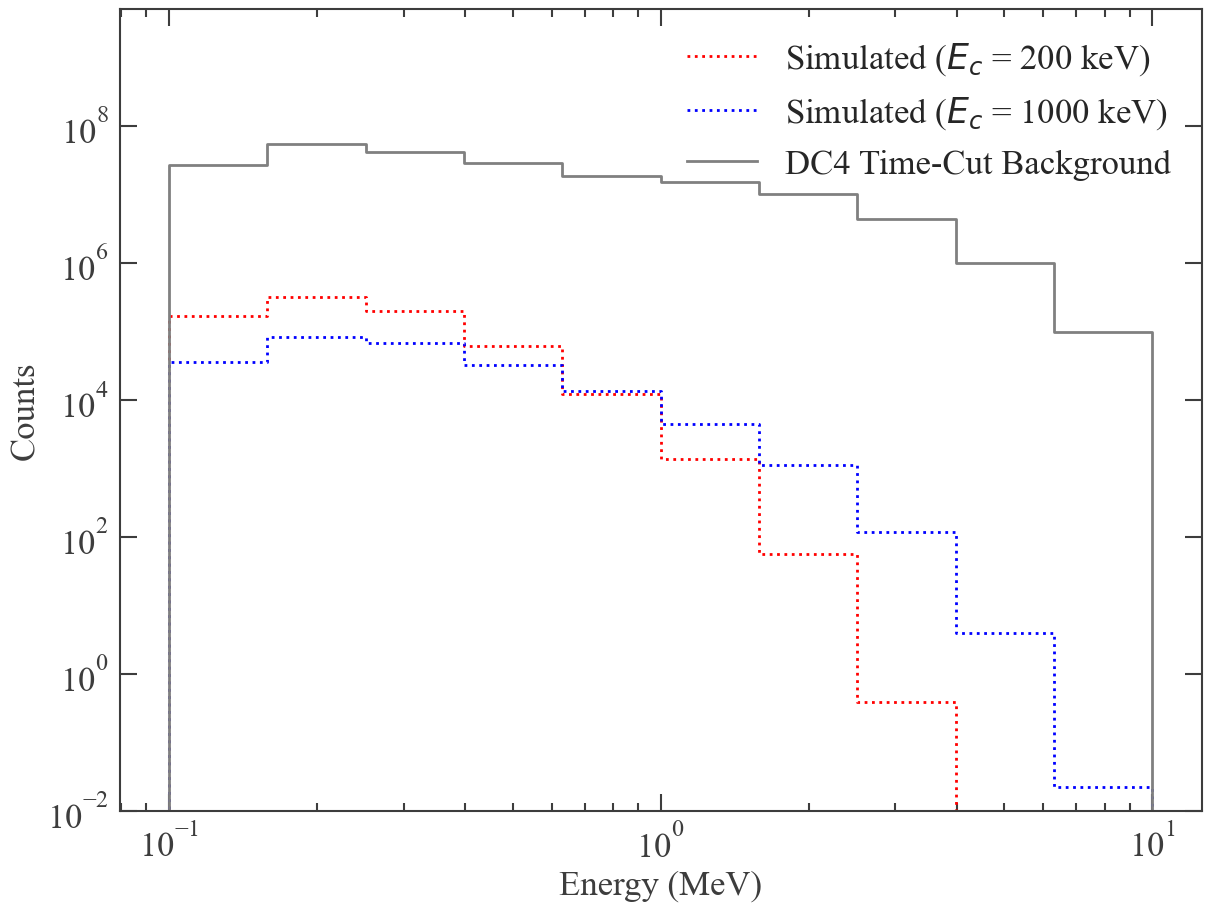

In [37]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

draw_energy_hist_mev(NGC4151_ec200, ax, label="Simulated ($E_c$ = 200 keV)", color="red", linestyle="dotted")
draw_energy_hist_mev(NGC4151_ec1000, ax, label="Simulated ($E_c$ = 1000 keV)", color="blue", linestyle="dotted")
draw_energy_hist_mev(bkg, ax, label="DC4 Time-Cut Background", color="grey")
# draw_energy_hist_mev(full_bkg, ax, label="DC4 Full Background", color="black", linestyle="dashdot")
# draw_energy_hist_mev(NGC4151_ec200_bkg, ax, label="NGC 4151 Model ($E_c$ = 200 keV) + Background", linestyle='dashdot', color="red")
# draw_energy_hist_mev(NGC4151_ec1000_bkg, ax, label="NGC 4151 Model ($E_c$ = 1000 keV) + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e9)

# ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1, 5]))
# ax.xaxis.set_major_formatter(
#     mticker.FixedFormatter(["0.2", "1.0", "5.0"])
# )

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='upper right', frameon=False)

# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_FullModel_Counts_200_1000_3Months.pdf"
# plt.savefig(save_path)

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [38]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter

# Finite support for cells that are empty in the background histogram.
# This value is added to every cell before the background template is normalized.
# Use finite background support to avoid machine-tiny TS inflation.
BACKGROUND_PSEUDOCOUNT = 1e-12
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

bkg_par_ec1000 = Parameter("background_cosi_ec1000",                           # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 background_pseudocount = BACKGROUND_PSEUDOCOUNT,              # regularize empty background cells
                 earth_occ = True)                                             # Option to account for Earth occultation

cosi_ec1000 = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par_ec1000,                                     # background parameter
                 background_pseudocount = BACKGROUND_PSEUDOCOUNT,              # regularize empty background cells
                 earth_occ = True)                                             # Option to account for Earth occultation

### Powerlaw with energy cutoff fit

In [39]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
# spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-8
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 100 # keep these relatively the same
spectrum_cpl.xc.max_value = 10000 # change to 1000
spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_cpl.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

source1 = PointSource("source1",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl)    # Spectral model

In [40]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1000. * u.keV
index = -1.75

spectrum_cpl_ec1000 = Cutoff_powerlaw()

spectrum_cpl_ec1000.K.value = K.value
spectrum_cpl_ec1000.piv.value = piv.value
spectrum_cpl_ec1000.xc.value = xc.value
spectrum_cpl_ec1000.index.value = index
# spectrum_cpl_ec1000.index.fix = True

# Harsher Parameters
spectrum_cpl_ec1000.K.min_value = 1e-8
spectrum_cpl_ec1000.K.max_value = 1e-2
spectrum_cpl_ec1000.xc.min_value = 100 # keep these relatively the same
spectrum_cpl_ec1000.xc.max_value = 10000 # change to 1000
# spectrum_cpl_ec1000.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
# spectrum_cpl_ec1000.index.max_value = 1

# spectrum_cpl_ec1000.K.delta = 0.05
# spectrum_cpl_ec1000.xc.delta = 10
# spectrum_cpl_ec1000.index.delta = 0.15

spectrum_cpl_ec1000.K.unit = K.unit
spectrum_cpl_ec1000.piv.unit = piv.unit
spectrum_cpl_ec1000.xc.unit = xc.unit

source2 = PointSource("source2",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl_ec1000)    # Spectral model

In [41]:
model = Model(source1)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model_ec1000 = Model(source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

cosi.set_model(model)
cosi_ec1000.set_model(model_ec1000)

### Joint Fit

In [42]:
# bat_ec200.use_effective_area_correction(0.02, 1.8)
# plugins = DataList(bat_ec200, cosi)

# bat_ec1000.use_effective_area_correction(0.02, 1.8)
# plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000)

### Only COSI Fit

In [43]:
## Only COSI fit
plugins = DataList(cosi)
plugins_ec1000 = DataList(cosi_ec1000)

### Bright and Dim Fit

In [44]:
like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()


13:46:48 INFO      set the minimizer to minuit                                             ]8;id=728152;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=43359;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=472690;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=107204;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(1.73 -0.23 +0.27) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.index,-1.73 +/- 0.17,
source1.spectrum.main.Cutoff_powerlaw.xc,(2.7 +/- 0.5) x 10^2,keV
background_cosi,(2.55708 +/- 0.00026) x 10,Hz


Correlation matrix:

...

1.00,0.41,-0.69,-0.33
0.41,1.00,-0.83,0.08
-0.69,-0.83,1.00,-0.15
-0.33,0.08,-0.15,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1314456781.571405
total,-1314456781.571405


Values of statistical measures:

,statistical measures
AIC,-2628913555.1426363
BIC,-2628913513.752521


In [45]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
def make_null_likelihood(data_hist):
    cosi_null = COSIPlugin("cosi",                                                # COSI 3ML plugin
                     dr = dr,                                                    # detector response
                     data = data_hist.project('Em', 'Phi', 'PsiChi'),            # data (source+background)
                     bkg = bkg.project('Em', 'Phi', 'PsiChi'),                   # background model
                     sc_orientation = sc_orientation,                            # spacecraft orientation
                     nuisance_param = bkg_par,                                   # background parameter
                     background_pseudocount = BACKGROUND_PSEUDOCOUNT,            # match the source fit
                     earth_occ = True)                                           # Match the source fits

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        "source_null",
        l=l,
        b=b,
        spectral_shape=spectrum_null,
    )

    model_null = Model(source_null)
    cosi_null.set_model(model_null)

    plugins_null = DataList(cosi_null)
    like_null = JointLikelihood(model_null, plugins_null, verbose=False)
    like_null.fit()

    return like_null

like_null_200 = make_null_likelihood(NGC4151_ec200_bkg)
like_null_1000 = make_null_likelihood(NGC4151_ec1000_bkg)

TS = 2 * (
    like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

TS_ec1000 = 2 * (
    like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

print("L1", -like.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS)
print("Significance [200 keV]: ", np.sqrt(TS))

print("L1", -like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS_ec1000)
print("Significance [1000 keV]: ", np.sqrt(TS_ec1000))

13:47:06 INFO      set the minimizer to minuit                                             ]8;id=670650;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=668584;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
background_cosi,(2.56699 +/- 0.00018) x 10,Hz


Correlation matrix:

1.00


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1314456364.628749
total,-1314456364.628749


Values of statistical measures:

,statistical measures
AIC,-2628912727.2574806
BIC,-2628912716.9099255


L1 1318682336.0389652
L0 1318679673.2544417
TS Value:  5325.569046974182
Significance [200 keV]:  72.97649653809219
L1 1314456781.571405
L0 1314456364.628749
TS Value:  833.8853120803833
Significance [1000 keV]:  28.87707242918477


In [46]:
from agn_cosi_fit_utils import (
    cosi_source_detection_ts,
    fit_cosi_exposure_from_results,
    load_agn_manifest_histograms,
    save_agn_fit_summary,
)

FIT_SUMMARY_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True"
)
DUAL_EXPOSURE_BACKGROUND_FILE = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)

def _dual_exposure_orientation(exposure_months):
    return scale_spacecraft_livetime(
        full_sc_orientation.apply_gti(source_gti), exposure_months / 3.0,
    )

# The plot remains based on the existing 24-month fits.  These additional
# native 3-month fits are calculated only for the combined text table.
bright_manifest_3m_path = sensitivity_dir / "Case1_bright" / (
    "NGC4151_bright_TH_median_realization_3months.json"
)
dim_manifest_3m_path = sensitivity_dir / "Case1_dim" / (
    "NGC4151_dim_TH_median_realization_3months.json"
)
_, _, bright_data_3m, bkg_3m = load_agn_manifest_histograms(
    bright_manifest_3m_path, DUAL_EXPOSURE_BACKGROUND_FILE, 3,
)
_, _, dim_data_3m, _ = load_agn_manifest_histograms(
    dim_manifest_3m_path, DUAL_EXPOSURE_BACKGROUND_FILE, 3,
)
sc_orientation_3m = _dual_exposure_orientation(3)

like_bright_3m, cosi_bright_3m = fit_cosi_exposure_from_results(
    reference_results=like.results, data_hist=bright_data_3m,
    background_hist=bkg_3m, dr_path=dr, sc_orientation=sc_orientation_3m,
    dataset_name="cosi_bright_3m",
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
)
like_dim_3m, cosi_dim_3m = fit_cosi_exposure_from_results(
    reference_results=like_ec1000.results, data_hist=dim_data_3m,
    background_hist=bkg_3m, dr_path=dr, sc_orientation=sc_orientation_3m,
    dataset_name="cosi_dim_3m",
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
)

TS_bright_3m, _ = cosi_source_detection_ts(like_bright_3m, cosi_bright_3m)
TS_dim_3m, _ = cosi_source_detection_ts(like_dim_3m, cosi_dim_3m)
TS_bright_24m, _ = cosi_source_detection_ts(like, cosi)
TS_dim_24m, _ = cosi_source_detection_ts(like_ec1000, cosi_ec1000)

fit_summary_path = save_agn_fit_summary(
    output_path=FIT_SUMMARY_DIR / "NGC4151_TH_Dim_Bright_global_fit_summary_3_24Months.txt",
    fit_results={
        "3m_bright": like_bright_3m.results,
        "3m_dim": like_dim_3m.results,
        "24m_bright": like.results,
        "24m_dim": like_ec1000.results,
    },
    injected_models={
        "3m_bright": {"thermal": spectrum_inj_ec200},
        "3m_dim": {"thermal": spectrum_inj_ec1000},
        "24m_bright": {"thermal": spectrum_inj_ec200},
        "24m_dim": {"thermal": spectrum_inj_ec1000},
    },
    ts_values={
        "3m_bright": TS_bright_3m, "3m_dim": TS_dim_3m,
        "24m_bright": TS_bright_24m, "24m_dim": TS_dim_24m,
    },
    exposure_months={
        "3m_bright": 3, "3m_dim": 3, "24m_bright": 24, "24m_dim": 24,
    },
    notes="Case 1 uses independently selected native 3- and 24-month ensemble representatives.",
)
print(f"Saved combined 3/24-month fit summary: {fit_summary_path}")


13:47:26 INFO      set the minimizer to minuit                                             ]8;id=394767;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=264676;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

13:47:37 INFO      set the minimizer to minuit                                             ]8;id=869364;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=66205;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Saved combined 3/24-month fit summary: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True/NGC4151_TH_Dim_Bright_global_fit_summary_3_24Months.txt


In [47]:
results = like.results
results_ec1000 = like_ec1000.results
results_sed = results
results_sed_ec1000 = results_ec1000
data_sed_hist = cosi._data.copy()
bkg_sed_hist = cosi._raw_bkg_hist.copy()
data_sed_ec1000_hist = cosi_ec1000._data.copy()
bkg_sed_ec1000_hist = cosi_ec1000._raw_bkg_hist.copy()

# print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source1"].parameters.values()
              if par.free}
parameters_ec1000 = {par.name:results_ec1000.get_variates(par.path)
              for par in results_ec1000.optimized_model["source2"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source1"].spectrum.main.shape.evaluate_at, **parameters)
results_err_ec1000 = results_ec1000.propagate(results_ec1000.optimized_model["source2"].spectrum.main.shape.evaluate_at, **parameters_ec1000)

# print(results.optimized_model["source"])

In [48]:
def _fit_includes_dataset(fit_results, dataset_name):
    try:
        return dataset_name in fit_results.get_statistic_frame().index
    except Exception:
        return False

has_bat_fit_200 = _fit_includes_dataset(results, 'BAT')
has_bat_fit_1000 = _fit_includes_dataset(results_ec1000, 'BAT')
has_any_bat_fit = has_bat_fit_200 or has_bat_fit_1000
flux_energy_min_keV = 100
flux_energy_max_keV = 10000
energy = np.geomspace(flux_energy_min_keV * u.keV, flux_energy_max_keV * u.keV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

    flux_ec1000 = results_err_ec1000(e)
    flux_median_ec1000[i] = flux_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1']
expectation_ec1000 = cosi_ec1000._expected_counts['source2']


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



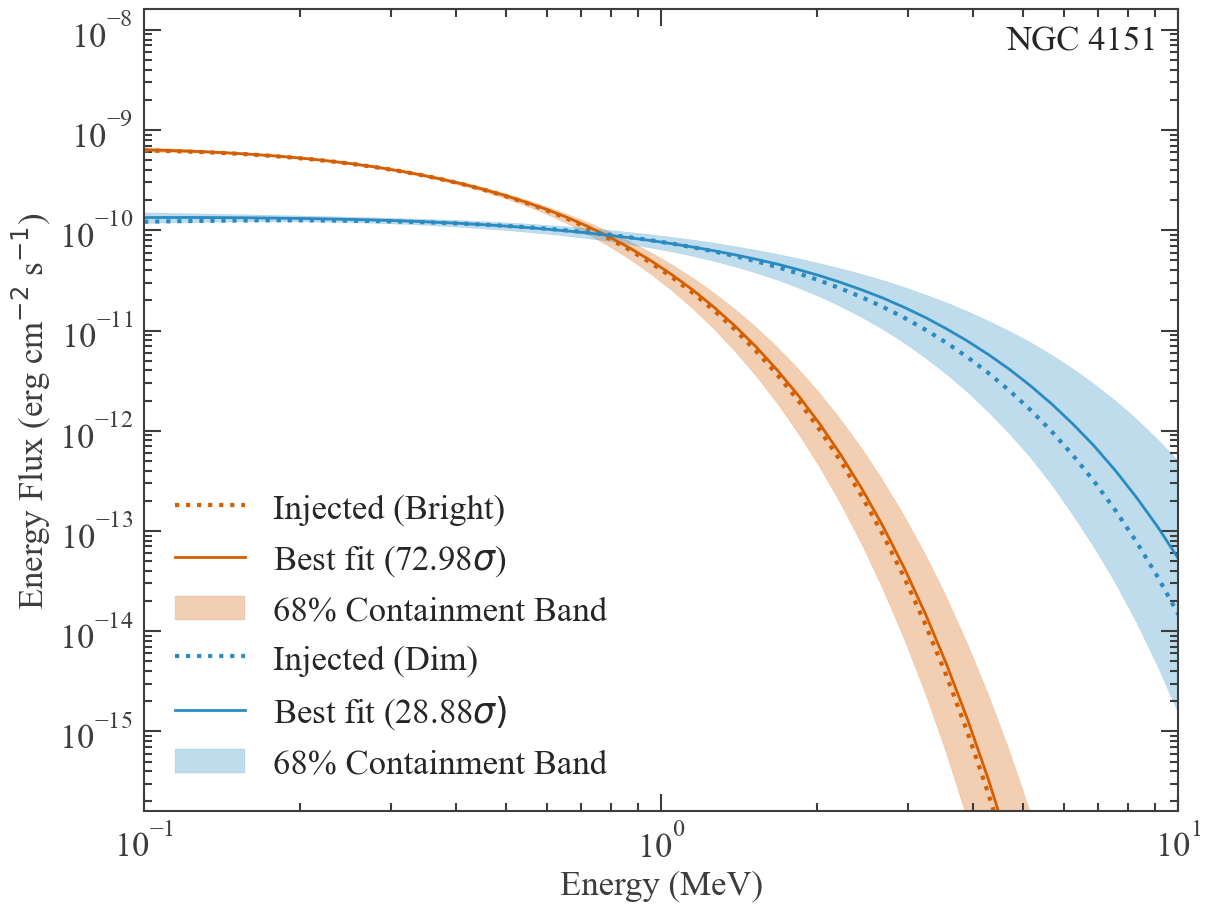

In [49]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_inj, color = '#D55E00', ls = ":", lw=3, label = "Injected (Bright)")
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median, color = '#D55E00', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_lo, SED_KEV_TO_ERG * energy * energy *flux_hi, alpha = .3, color = '#D55E00', label = "68% Containment Band")

ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_inj_ec1000, color = '#2A8BC3', ls = ":", lw=3, label = "Injected (Dim)")
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median_ec1000, color = '#2A8BC3', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_lo_ec1000, SED_KEV_TO_ERG * energy * energy *flux_hi_ec1000, alpha = .3, color='#2A8BC3', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_ThModel_TH_Fit_200_1000_24Months.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7 * SED_KEV_TO_ERG, 10 * SED_KEV_TO_ERG)

ax.set_xlim((100) * KEV_TO_MEV, (10000) * KEV_TO_MEV)

# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(
#     mticker.FixedFormatter(["0.1", "5", "10"])
# )

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

## Thermal SED (COSI-only)

This extracts a bin-by-bin SED from the thermal COSI-only fit. The photon index is frozen to the global-fit value in every bin. Because a single measured-energy band will not constrain the cutoff reliably, the helper below also fixes `xc` to the global-fit value. By default the COSI background nuisance parameter is left free, which matches the earlier working bin-by-bin behavior. You can optionally freeze it to a chosen reference value if you want a stricter one-parameter SED extraction. The helper also records whether a bin lands on the `K` lower bound, and if requested it can relax that lower bound and retry once before evaluating profile errors. You can also pass a stricter Minuit `ftol` to make the per-bin fits converge more tightly before MINOS is evaluated. If a manual fallback profile finds only an upper crossing, you can either keep that bin as an upper limit or convert it into a lower-bound-to-upper-crossing interval for plotting.


In [50]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
def _iter_model_sources(model):
    return [
        (name, child)
        for name, child in getattr(model, '_children', {}).items()
        if hasattr(child, 'spectrum')
    ]


def _get_source_spectral_shape(source, shape_name='Cutoff_powerlaw'):
    main_component = source.spectrum.main

    try:
        return getattr(main_component, shape_name)
    except AttributeError:
        shape = getattr(main_component, 'shape', None)
        if shape is not None and shape.__class__.__name__ == shape_name:
            return shape

    return None


def _resolve_source_name(model, source_name=None, shape_name='Cutoff_powerlaw'):
    sources = _iter_model_sources(model)

    if source_name is not None:
        source_names = [name for name, _ in sources]
        if source_name not in source_names:
            raise ValueError(f'Source {source_name!r} is not in optimized model. Available sources: {source_names}.')

        source = model[source_name]
        if _get_source_spectral_shape(source, shape_name=shape_name) is None:
            raise ValueError(f'Source {source_name!r} does not contain a {shape_name} shape.')

        return source_name

    source_names = [
        name
        for name, source in sources
        if _get_source_spectral_shape(source, shape_name=shape_name) is not None
    ]

    if len(source_names) != 1:
        raise ValueError(
            f'Expected one source with a {shape_name} shape, found {source_names}. '
            'Pass source_name to select the SED target explicitly.'
        )

    return source_names[0]


def _get_cutoff_powerlaw_shape(global_results, source_name=None):
    optimized_model = global_results.optimized_model
    source_name = _resolve_source_name(optimized_model, source_name=source_name)

    return _get_source_spectral_shape(optimized_model[source_name]), source_name


def build_thermal_sed_model(global_results, freeze_cutoff=True, source_name=None, freeze_non_target_parameters=True):
    from astromodels import clone_model

    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    sed_model = clone_model(global_results.optimized_model)
    fit_shape = _get_source_spectral_shape(sed_model[source_name])

    if freeze_non_target_parameters:
        for parameter in sed_model.parameters.values():
            parameter.fix = True

    fit_shape.K.value = best_fit_shape.K.value
    fit_shape.K.min_value = max(best_fit_shape.K.value * 1e-3, 1e-12)
    fit_shape.K.max_value = best_fit_shape.K.value * 1e3
    fit_shape.K.fix = False
    fit_shape.index.value = best_fit_shape.index.value
    fit_shape.index.fix = True
    fit_shape.xc.value = best_fit_shape.xc.value
    fit_shape.xc.fix = freeze_cutoff

    return sed_model


def _hist_sum(hist):
    contents = hist.contents
    if hasattr(contents, 'todense'):
        contents = contents.todense()
    if hasattr(contents, 'value'):
        contents = contents.value
    return float(np.asarray(contents).sum())


def _evaluate_model_photon_flux(model, energy):
    photon_flux = 0.0

    for _, source in _iter_model_sources(model):
        photon_flux += float(source.spectrum.main.shape.evaluate_at(energy))

    return photon_flux


def _with_target_k_value(model, source_name, k_value, evaluator):
    target_shape = _get_source_spectral_shape(model[source_name])
    k_parameter = target_shape.K
    original_k = float(k_parameter.value)
    original_min = k_parameter.min_value
    original_max = k_parameter.max_value
    requested_k = float(k_value)

    # Manual profiling can expand the live fit-model bound after the optimized
    # model snapshot was created. Temporarily give that snapshot enough range
    # to evaluate the resulting confidence endpoint.
    if original_min is not None and requested_k < float(original_min):
        k_parameter.min_value = requested_k
    if original_max is not None and requested_k > float(original_max):
        k_parameter.max_value = requested_k

    k_parameter.value = requested_k

    try:
        return evaluator()
    finally:
        k_parameter.value = original_k
        k_parameter.min_value = original_min
        k_parameter.max_value = original_max


def _integrate_model_energy_flux(model, source_name, k_value, e_min, e_max, n_points=256):
    energy_grid = np.geomspace(e_min, e_max, n_points)

    def evaluator():
        return np.asarray([_evaluate_model_photon_flux(model, energy) for energy in energy_grid])

    photon_flux = _with_target_k_value(model, source_name, k_value, evaluator)
    trapezoid = getattr(np, 'trapezoid', None)
    if trapezoid is None:
        trapezoid = np.trapz
    return float(trapezoid(energy_grid * photon_flux, energy_grid))


def _evaluate_model_sed_flux(model, source_name, k_value, energy):
    return _with_target_k_value(
        model,
        source_name,
        k_value,
        lambda: float(energy**2 * _evaluate_model_photon_flux(model, energy)),
    )


def _extract_profile_error(errors, suffix):
    if hasattr(errors, 'index'):
        for parameter_path in errors.index:
            if str(parameter_path).endswith(suffix):
                row = errors.loc[parameter_path]
                return float(row['negative_error']), float(row['positive_error'])
        return None

    for parameter_path, interval in errors.items():
        if str(parameter_path).endswith(suffix):
            return interval
    return None


def _get_global_background_scale(global_results, default=1.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    for parameter_path in results_frame.index:
        if str(parameter_path).startswith('background_'):
            return float(results_frame.loc[parameter_path, 'value'])

    return float(default)


def _run_joint_likelihood_fit(joint_likelihood):
    fit_status = 'covariance'
    try:
        joint_likelihood.fit(quiet=True)
    except Exception as exc:
        fit_status = f'no-covariance fallback ({type(exc).__name__})'
        joint_likelihood.fit(quiet=True, compute_covariance=False)
    return fit_status


def _get_joint_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()

    if '-log(likelihood)' in statistic_frame.columns:
        statistic_column = statistic_frame['-log(likelihood)']
    else:
        numeric_frame = statistic_frame.select_dtypes(include=[np.number])
        if numeric_frame.empty:
            raise ValueError(f'No numeric statistic columns found in {list(statistic_frame.columns)}.')
        statistic_column = numeric_frame.iloc[:, 0]

    if 'total' in statistic_column.index:
        return float(statistic_column.loc['total'])

    return float(statistic_column.sum())


def _ts_to_sigma(ts_value):
    if not np.isfinite(ts_value) or ts_value <= 0:
        return 0.0

    return float(np.sqrt(ts_value))


def _build_null_sed_model(
    global_results,
    source_name,
    freeze_cutoff=True,
    freeze_non_target_parameters=True,
    null_k_value=1e-30,
):
    null_model = build_thermal_sed_model(
        global_results,
        freeze_cutoff=freeze_cutoff,
        source_name=source_name,
        freeze_non_target_parameters=freeze_non_target_parameters,
    )
    null_shape = _get_source_spectral_shape(null_model[source_name])
    null_k_value = max(float(null_k_value), np.finfo(float).tiny)
    null_k_min = max(null_k_value * 0.1, np.finfo(float).tiny)
    null_shape.K.min_value = min(float(null_shape.K.min_value or null_k_min), null_k_min)
    null_shape.K.value = null_k_value
    null_shape.K.fix = True

    return null_model


def _make_minuit_with_ftol(minuit_ftol):
    if minuit_ftol is None:
        return None

    minuit = LocalMinimization('minuit')
    minuit.setup(ftol=float(minuit_ftol))

    return minuit


def _hits_lower_bound(value, lower_bound):
    if lower_bound is None or not np.isfinite(lower_bound):
        return False

    atol = max(1e-18, abs(float(lower_bound)) * 1e-6)
    return bool(np.isclose(float(value), float(lower_bound), rtol=1e-3, atol=atol))


def _interpolate_profile_crossing(x1, y1, x2, y2, target):
    if np.isclose(y1, y2):
        return float(0.5 * (x1 + x2))

    fraction = float((target - y1) / (y2 - y1))
    fraction = float(np.clip(fraction, 0.0, 1.0))

    if x1 > 0 and x2 > 0:
        return float(np.exp(np.log(x1) + fraction * (np.log(x2) - np.log(x1))))

    return float(x1 + fraction * (x2 - x1))


def _find_profile_crossing(x_values, delta_ts, threshold, side):
    if len(x_values) == 0:
        return None

    minimum_index = int(np.nanargmin(delta_ts))

    if side == 'left':
        for index in range(minimum_index - 1, -1, -1):
            y1 = float(delta_ts[index])
            y2 = float(delta_ts[index + 1])
            if np.isnan(y1) or np.isnan(y2):
                continue
            if np.isclose(y1, threshold):
                return float(x_values[index])
            if (y1 - threshold) * (y2 - threshold) <= 0:
                return _interpolate_profile_crossing(
                    float(x_values[index]),
                    y1,
                    float(x_values[index + 1]),
                    y2,
                    threshold,
                )
        return None

    for index in range(minimum_index, len(x_values) - 1):
        y1 = float(delta_ts[index])
        y2 = float(delta_ts[index + 1])
        if np.isnan(y1) or np.isnan(y2):
            continue
        if np.isclose(y2, threshold):
            return float(x_values[index + 1])
        if (y1 - threshold) * (y2 - threshold) <= 0:
            return _interpolate_profile_crossing(
                float(x_values[index]),
                y1,
                float(x_values[index + 1]),
                y2,
                threshold,
            )

    return None


def _manual_k_profile_interval(
    joint_likelihood,
    parameter_path,
    center_value,
    lower_bound,
    upper_bound,
    n_steps=61,
    target_delta_ts=1.0,
    max_expansions=12,
    scan_expand_factor=1e2,
):
    if center_value <= 0:
        raise ValueError('Manual K profiling requires a positive best-fit normalization.')

    tiny_positive = float(np.finfo(float).tiny)
    scan_min = max(float(lower_bound), tiny_positive)
    scan_max = float(upper_bound) if np.isfinite(upper_bound) else float(center_value) * 1e6

    if not np.isfinite(scan_max) or scan_max <= scan_min:
        raise ValueError('Invalid K scan bounds for manual profiling.')

    import matplotlib.pyplot as plt

    left_crossing = None
    right_crossing = None

    for _ in range(max_expansions + 1):
        x_values, _, profile_values, profile_figure = joint_likelihood.get_contours(
            parameter_path,
            param_1_minimum=float(scan_min),
            param_1_maximum=float(scan_max),
            param_1_n_steps=int(n_steps),
            progress=False,
            log=(True,),
        )
        plt.close(profile_figure)

        x_values = np.asarray(x_values, dtype=float)
        profile_values = np.asarray(profile_values, dtype=float)
        delta_ts = 2.0 * (profile_values - np.nanmin(profile_values))
        minimum_index = int(np.nanargmin(delta_ts))

        left_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'left')
        right_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'right')

        if left_crossing is not None and right_crossing is not None:
            status = f'manual K profile ok ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
            return float(left_crossing), float(right_crossing), status

        expanded = False

        if left_crossing is None and minimum_index > 0 and delta_ts[0] < target_delta_ts and scan_min > lower_bound:
            new_scan_min = max(float(lower_bound), float(scan_min) / scan_expand_factor)
            if new_scan_min < scan_min:
                scan_min = new_scan_min
                expanded = True

        if right_crossing is None and minimum_index < (len(x_values) - 1) and delta_ts[-1] < target_delta_ts and scan_max < upper_bound:
            new_scan_max = min(float(upper_bound), float(scan_max) * scan_expand_factor)
            if new_scan_max > scan_max:
                scan_max = new_scan_max
                expanded = True

        if not expanded:
            break

    status = f'manual K profile incomplete ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
    return left_crossing, right_crossing, status


def fit_thermal_cosi_sed(
    global_results,
    data_hist,
    bkg_hist,
    dr_path,
    sc_orientation,
    source_name=None,
    n_sed_bins=5,
    freeze_cutoff=True,
    freeze_non_target_parameters=True,
    freeze_background=False,
    background_scale_value=None,
    minuit_ftol=None,
    error_estimation='minos_then_manual',
    manual_k_profile_points=61,
    manual_one_sided_mode='upper_limit',
    relax_k_lower_bound=True,
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e2,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    em_edges = data_hist.axes['Em'].edges.to_value(u.keV)
    native_em_bins = np.flatnonzero(
        (em_edges[:-1] >= energy_min_keV) & (em_edges[1:] <= energy_max_keV)
    )

    if len(native_em_bins) == 0:
        raise ValueError(
            f'No native Em bins are fully contained in {energy_min_keV}-{energy_max_keV} keV.'
        )

    def _split_last_group_remainder(arr, n_groups):
        arr = np.asarray(arr)
        if len(arr) < n_groups:
            raise ValueError(f"Need at least {n_groups} native bins, got {len(arr)}.")

        sizes = [1] * (n_groups - 1)
        sizes.append(len(arr) - (n_groups - 1))

        groups = []
        start = 0
        for size in sizes:
            groups.append(arr[start:start + size])
            start += size

        return groups

    grouped_bins = _split_last_group_remainder(native_em_bins, n_sed_bins)

    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_background_scale = _get_global_background_scale(global_results, default=1.0)

    if background_scale_value is not None:
        background_scale_value = float(background_scale_value)

    for sed_bin_index, group in enumerate(grouped_bins, start=1):
        em_slice = slice(int(group[0]), int(group[-1]) + 1)
        e_min = float(em_edges[group[0]])
        e_max = float(em_edges[group[-1] + 1])
        e_ref = float(np.sqrt(e_min * e_max))
        data_counts = _hist_sum(data_hist.slice[{'Em': em_slice}])
        background_counts = _hist_sum(bkg_hist.slice[{'Em': em_slice}])

        dataset_name = f'cosi_sed_bin_{sed_bin_index}'

        bin_cosi = EnergyRangeCOSIPlugin(
            name=dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            background_pseudocount=background_pseudocount,
            nuisance_param=make_cosi_background_parameter(dataset_name),
            earth_occ=True,
        )

        background_parameter = bin_cosi.nuisance_parameters[f'background_{dataset_name}']

        if freeze_background:
            if background_scale_value is None:
                background_parameter.value = global_background_scale
            else:
                background_parameter.value = background_scale_value
            background_parameter.fix = True
        else:
            background_parameter.fix = False
            if background_scale_value is not None:
                background_parameter.value = background_scale_value

        bin_model = build_thermal_sed_model(
            global_results,
            freeze_cutoff=freeze_cutoff,
            source_name=source_name,
            freeze_non_target_parameters=freeze_non_target_parameters,
        )
        bin_like = JointLikelihood(bin_model, DataList(bin_cosi), verbose=False)

        bin_minuit = _make_minuit_with_ftol(minuit_ftol)
        if bin_minuit is not None:
            bin_like.set_minimizer(bin_minuit)

        # threeML can reject every covariance sample in weak bins and then crash while building the summary table.
        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        if relax_k_lower_bound and _hits_lower_bound(k_value, k_min):
            relaxed_k_min = max(k_min * 1e-2, 1e-18)
            if relaxed_k_min < k_min:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.min_value = relaxed_k_min
                retry_status = _run_joint_likelihood_fit(bin_like)
                fit_status = f'{fit_status}; relaxed K min to {relaxed_k_min:.3e}; retry={retry_status}'
                bin_results = bin_like.results
                fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
                k_value = float(fit_shape.K.value)
                k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
                k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
                k_lower_bound_relaxed = True

        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_dataset_name = f'{dataset_name}_null'
        null_cosi = EnergyRangeCOSIPlugin(
            name=null_dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            background_pseudocount=background_pseudocount,
            nuisance_param=make_cosi_background_parameter(null_dataset_name),
            earth_occ=True,
        )

        null_background_parameter = null_cosi.nuisance_parameters[f'background_{null_dataset_name}']
        if freeze_background:
            if background_scale_value is None:
                null_background_parameter.value = global_background_scale
            else:
                null_background_parameter.value = background_scale_value
            null_background_parameter.fix = True
        else:
            null_background_parameter.fix = False
            if background_scale_value is not None:
                null_background_parameter.value = background_scale_value
            else:
                null_background_parameter.value = float(background_parameter.value)

        null_model = _build_null_sed_model(
            global_results,
            source_name=source_name,
            freeze_cutoff=freeze_cutoff,
            freeze_non_target_parameters=freeze_non_target_parameters,
        )
        null_like = JointLikelihood(null_model, DataList(null_cosi), verbose=False)

        null_minuit = _make_minuit_with_ftol(minuit_ftol)
        if null_minuit is not None:
            null_like.set_minimizer(null_minuit)

        null_fit_status = _run_joint_likelihood_fit(null_like)
        joint_null_statistic = _get_joint_likelihood_statistic(null_like)
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, float(ts_value_raw))
        sigma = _ts_to_sigma(ts_value)

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, '.K')
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, '.K')
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value = profile_k_max
                k_max = float(bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value)

            k_path = f'{source_name}.spectrum.main.Cutoff_powerlaw.K'
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        integrated_flux = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_value, e_min, e_max)
        integrated_flux_lo = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_lo, e_min, e_max)
        integrated_flux_hi = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_hi, e_min, e_max)
        sed_flux = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_value, e_ref)
        sed_flux_lo = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_lo, e_ref)
        sed_flux_hi = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_hi, e_ref)
        background_scale = float(bin_cosi.nuisance_parameters[f'background_{dataset_name}'].value)
        background_is_fixed = bool(background_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )

        sed_rows.append(
            {
                'bin_index': sed_bin_index,
                'source_name': source_name,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_erg_cm2_s': integrated_flux,
                'bin_energy_flux_lo_erg_cm2_s': integrated_flux_lo,
                'bin_energy_flux_hi_erg_cm2_s': integrated_flux_hi,
                'sed_erg_cm2_s': sed_flux,
                'sed_lo_erg_cm2_s': sed_flux_lo,
                'sed_hi_erg_cm2_s': sed_flux_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'background_scale': background_scale,
                'background_scale_reference': (
                    global_background_scale if background_scale_value is None else background_scale_value
                ),
                'background_requested_fixed': freeze_background,
                'background_scale_fixed': background_is_fixed,
                'background_released_for_retry': False,
                'data_counts': data_counts,
                'background_counts': background_counts,
                'background_pseudocount': background_pseudocount,
                'excess_counts': data_counts - background_counts,
                'joint_statistic': joint_statistic,
                'joint_null_statistic': joint_null_statistic,
                'ts_value_raw': ts_value_raw,
                'ts_value': ts_value,
                'sigma': sigma,
                'null_fit_status': null_fit_status,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    sed_df = pd.DataFrame(sed_rows)
    energy_flux_columns = [
        column for column in sed_df.columns
        if column.endswith("_erg_cm2_s")
    ]
    sed_df[energy_flux_columns] *= SED_KEV_TO_ERG
    return sed_df

In [51]:
n_thermal_sed_bins = 8

# # Manual Scan
# thermal_cosi_sed_df = fit_thermal_cosi_sed(
#     global_results=results_sed,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df = fit_thermal_cosi_sed(
    global_results=results_sed,
    data_hist=data_sed_hist,
    bkg_hist=bkg_sed_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e6,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
)


display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "background_pseudocount",
            "excess_counts",
            "joint_statistic",
            "joint_null_statistic",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

13:47:48 INFO      set the minimizer to minuit                                             ]8;id=422209;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=441596;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=621820;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=189234;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=8428;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=702148;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=93629;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=211998;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=419073;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=331985;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

         INFO      set the minimizer to minuit                                             ]8;id=93631;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=545641;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=154282;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=51741;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=389878;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=1918;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s
0,1,100.000,158.489,125.892414,2.872969e-10,2.797183e-10,2.948776e-10
1,2,158.489,251.189,199.526172,2.391448e-10,2.347685e-10,2.435220e-10
2,3,251.189,398.107,316.227923,1.836483e-10,1.793580e-10,1.879399e-10
3,4,398.107,630.957,501.186989,1.042749e-10,9.869526e-11,1.098567e-10
4,5,630.957,1000.000,794.328018,3.284892e-11,2.467574e-11,4.102706e-11
5,6,1000.000,1584.890,1258.924144,9.139828e-12,9.139828e-15,2.272856e-11
6,7,1584.890,2511.890,1995.261723,3.975163e-15,8.462538e-16,7.048392e-12
7,8,2511.890,10000.000,5011.875896,9.535721e-17,2.096854e-17,7.994854e-12


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,background_pseudocount,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,1.764873e-05,1.718318e-05,0.000018,1.018013,25.570789,25.570789,True,True,False,27143315.0,26969712.0,1.000000e-12,173603.0,-1.809146e+08,-1.809136e+08,2078.599059,45.591656,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
1,2,1.701408e-05,1.670272e-05,0.000017,0.981405,25.570789,25.570789,True,True,False,54584750.0,54265544.0,1.000000e-12,319206.0,-3.942939e+08,-3.942922e+08,3345.720340,57.842202,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
2,3,1.770129e-05,1.728776e-05,0.000018,1.021045,25.570789,25.570789,True,True,False,41928499.0,41723608.0,1.000000e-12,204891.0,-2.875825e+08,-2.875813e+08,2373.052398,48.713986,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
3,4,1.738930e-05,1.645882e-05,0.000018,1.003049,25.570789,25.570789,True,True,False,28383141.0,28320824.0,1.000000e-12,62317.0,-1.805843e+08,-1.805840e+08,525.603956,22.926054,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
4,5,1.383528e-05,1.039290e-05,0.000017,0.798046,25.570789,25.570789,True,True,False,18712112.0,18701936.0,1.000000e-12,10176.0,-1.110868e+08,-1.110867e+08,16.174725,4.021781,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
5,6,1.733645e-05,1.733645e-08,0.000043,1.000000,25.570789,25.570789,True,True,False,14975730.0,14971952.0,1.000000e-12,3778.0,-8.569148e+07,-8.569148e+07,0.478767,0.691930,covariance,covariance,manual K profile lower-bound interval (201 poi...,manual lower-bound interval,0.01,minos_then_manual,False,False,False
6,7,8.143563e-08,1.733645e-08,0.000144,0.004697,25.570789,25.570789,True,True,False,10140952.0,10142000.0,1.000000e-12,-1048.0,-5.460636e+07,-5.460636e+07,0.000000,0.000000,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
7,8,7.883981e-08,1.733645e-08,0.006610,0.004548,25.570789,25.570789,True,True,False,5468938.0,5472696.0,1.000000e-12,-3758.0,-2.392249e+07,-2.392249e+07,0.000000,0.000000,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False


In [52]:
n_thermal_sed_bins = 10

# # Manual Scan
# thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
#     global_results=results_sed_ec1000,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     manual_one_sided_mode='lower_bound_interval',
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
    global_results=results_sed_ec1000,
    data_hist=data_sed_ec1000_hist,
    bkg_hist=bkg_sed_ec1000_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=81,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e3,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "background_pseudocount",
            "excess_counts",
            "joint_statistic",
            "joint_null_statistic",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "manual_one_sided_mode",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

         INFO      set the minimizer to minuit                                             ]8;id=354585;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=889558;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=951611;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=366146;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

13:47:54 INFO      set the minimizer to minuit                                             ]8;id=727301;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=631588;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=305205;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=347073;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=999432;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=29490;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

         INFO      set the minimizer to minuit                                             ]8;id=922272;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=289899;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=420492;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=299545;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=34430;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=533899;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s
0,1,100.000,158.489,125.892414,6.645142e-11,5.934086e-11,7.359174e-11
1,2,158.489,251.189,199.526172,5.986798e-11,5.563609e-11,6.409918e-11
2,3,251.189,398.107,316.227923,5.659215e-11,4.881717e-11,6.387410e-11
3,4,398.107,630.957,501.186989,5.365005e-11,4.815690e-11,5.916611e-11
4,5,630.957,1000.000,794.328018,4.544361e-11,3.716367e-11,5.372748e-11
5,6,1000.000,1584.890,1258.924144,3.097875e-11,1.696140e-11,4.500155e-11
6,7,1584.890,2511.890,1995.261723,3.073700e-11,1.368930e-11,5.100572e-11
7,8,2511.890,3981.070,3162.279229,9.960338e-15,6.944916e-15,7.083773e-12
8,9,3981.070,6309.570,5011.869895,1.719040e-17,1.651455e-17,4.950114e-12
9,10,6309.570,10000.000,7943.280179,8.423846e-16,1.763847e-16,7.621293e-12


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,background_pseudocount,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,manual_one_sided_mode,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,2.625480e-06,2.344543e-06,0.000003,1.067458,25.571102,25.571102,True,True,False,27016927.0,26969712.0,1.000000e-12,47215.0,-1.799442e+08,-1.799441e+08,312.305246,17.672160,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
1,2,2.403150e-06,2.233278e-06,0.000003,0.977064,25.571102,25.571102,True,True,False,54341106.0,54265544.0,1.000000e-12,75562.0,-3.922704e+08,-3.922703e+08,244.900785,15.649306,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
2,3,2.393493e-06,2.064660e-06,0.000003,0.973138,25.571102,25.571102,True,True,False,41789076.0,41723608.0,1.000000e-12,65468.0,-2.864840e+08,-2.864838e+08,321.024287,17.917151,covariance,covariance,"manual K profile ok (81 points, 2.460e-09-2.46...",manual profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
3,4,2.532068e-06,2.272814e-06,0.000003,1.029479,25.571102,25.571102,True,True,False,28355245.0,28320824.0,1.000000e-12,34421.0,-1.803782e+08,-1.803781e+08,183.119252,13.532156,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
4,5,2.620090e-06,2.142703e-06,0.000003,1.065267,25.571102,25.571102,True,True,False,18717092.0,18701936.0,1.000000e-12,15156.0,-1.111196e+08,-1.111196e+08,30.185095,5.494096,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
5,6,2.515225e-06,1.377130e-06,0.000004,1.022631,25.571102,25.571102,True,True,False,14976508.0,14971952.0,1.000000e-12,4556.0,-8.570201e+07,-8.570201e+07,4.888218,2.210932,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
6,7,4.388041e-06,1.954296e-06,0.000007,1.784074,25.571102,25.571102,True,True,False,10142808.0,10142000.0,1.000000e-12,808.0,-5.461982e+07,-5.461979e+07,47.181015,6.868844,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
7,8,3.527483e-09,2.459562e-09,0.000003,0.001434,25.571102,25.571102,True,True,False,4376984.0,4376160.0,1.000000e-12,824.0,-2.027989e+07,-2.027989e+07,0.000000,0.000000,covariance,covariance,manual K profile lower-bound interval (81 poin...,manual lower-bound interval,0.01,minos_then_manual,lower_bound_interval,False,True,False
8,9,2.560219e-11,2.459562e-11,0.000007,0.000010,25.571102,25.571102,True,True,False,998750.0,999728.0,1.000000e-12,-978.0,-3.457401e+06,-3.457401e+06,0.000000,0.000000,covariance; relaxed K min to 2.460e-11; retry=...,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,True,True,False
9,10,1.174647e-08,2.459562e-09,0.000106,0.004776,25.571102,25.571102,True,True,False,96034.0,96808.0,1.000000e-12,-774.0,-2.011871e+05,-2.011871e+05,0.000000,0.000000,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,True,False


In [53]:
FONT_SIZE = 25

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update(
    {
        "font.weight": "550",
        "axes.titleweight": "550",
        "axes.labelweight": "550",
    }
)

def _make_xerr(df):
    return KEV_TO_MEV * np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )

def _split_sed_detections(df, ts_threshold=4.0, min_plot_ts=1.0):
    if 'plot_role' in df.columns:
        roles = df['plot_role'].astype(str)
        return (
            df.loc[roles == 'detection'].copy(),
            df.loc[roles == 'upper_limit'].copy(),
        )

    plot_mask = np.ones(len(df), dtype=bool)
    upper_limit_mask = df['is_upper_limit'].copy()

    if 'ts_value' in df.columns:
        plot_mask = df['ts_value'] >= min_plot_ts
        upper_limit_mask = upper_limit_mask | (df['ts_value'] < ts_threshold)

    return (
        df.loc[plot_mask & ~upper_limit_mask].copy(),
        df.loc[plot_mask & upper_limit_mask].copy(),
    )

def _style_sed_axis(ax):
    ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
    ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim((85) * KEV_TO_MEV, (12000) * KEV_TO_MEV)
    ax.set_ylim(1e-3 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)

    # ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
    # ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.1", "5", "10"]))

    ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
    ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)


### Plot A — representative median data set

SED bin values and point/upper-limit decisions come only from the selected representative realization.


Plot A: representative median data set; classification uses its own bin TS.


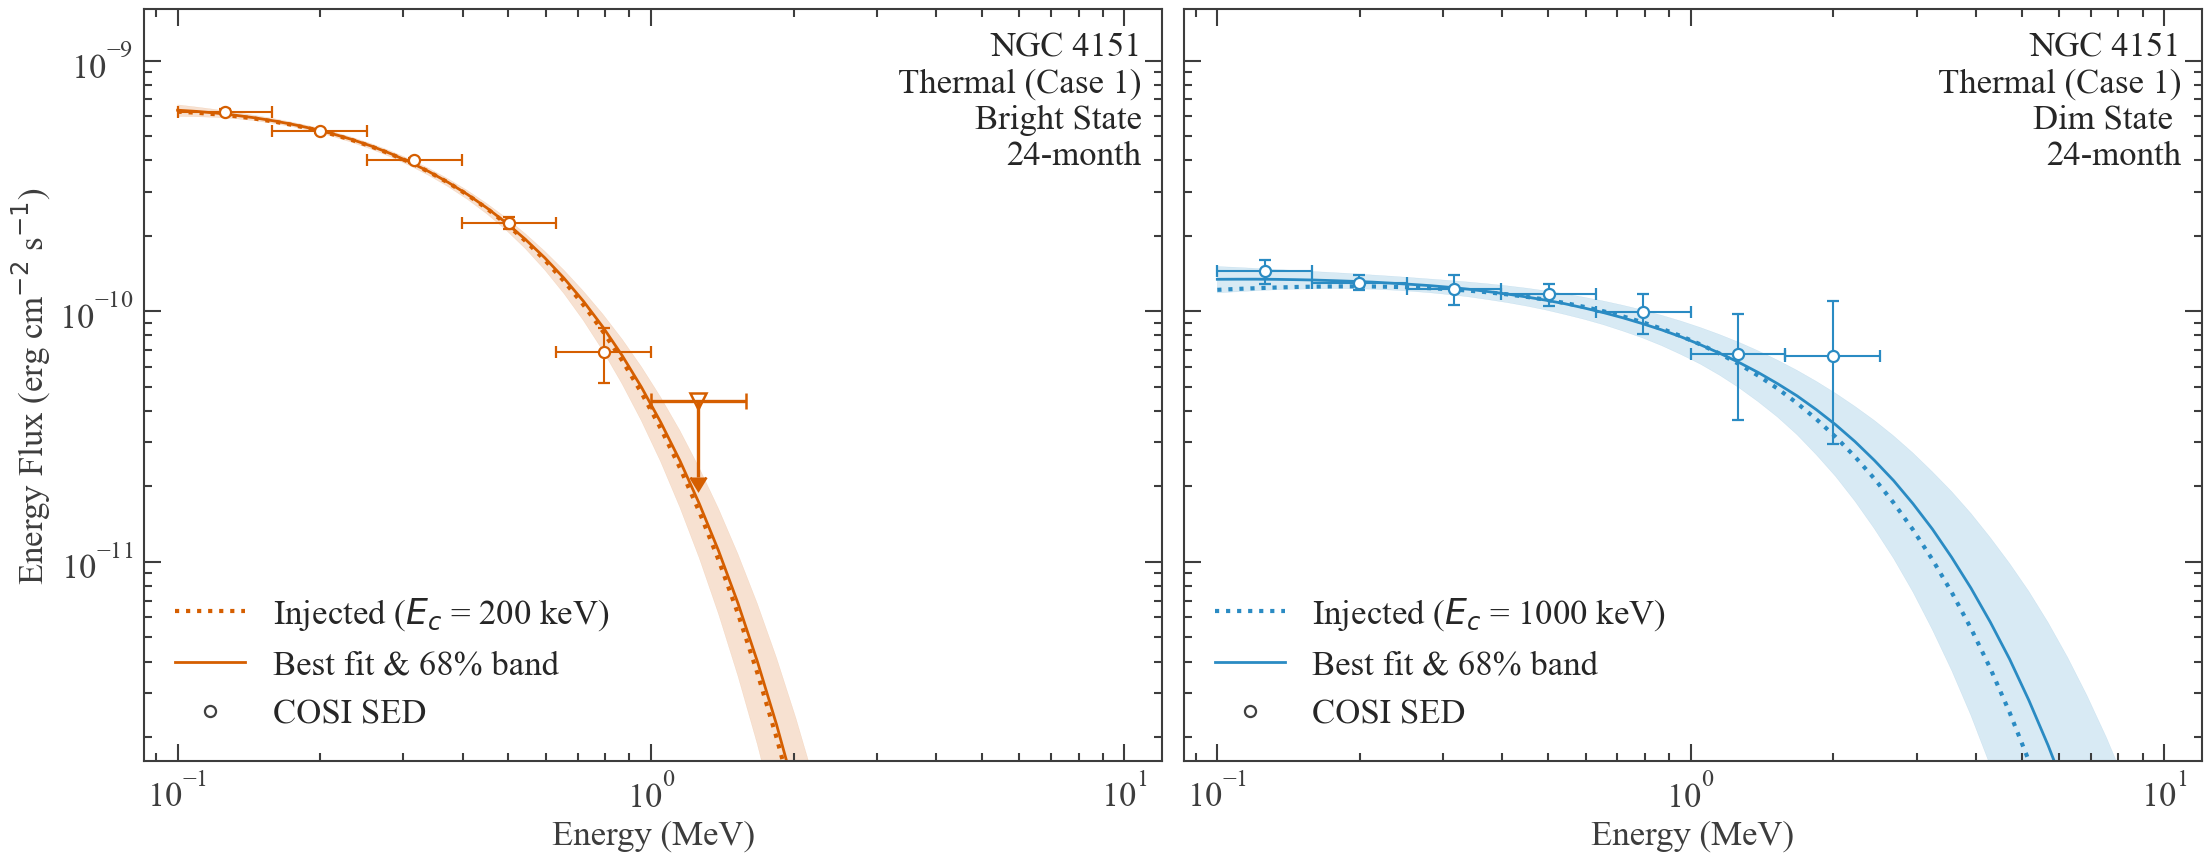

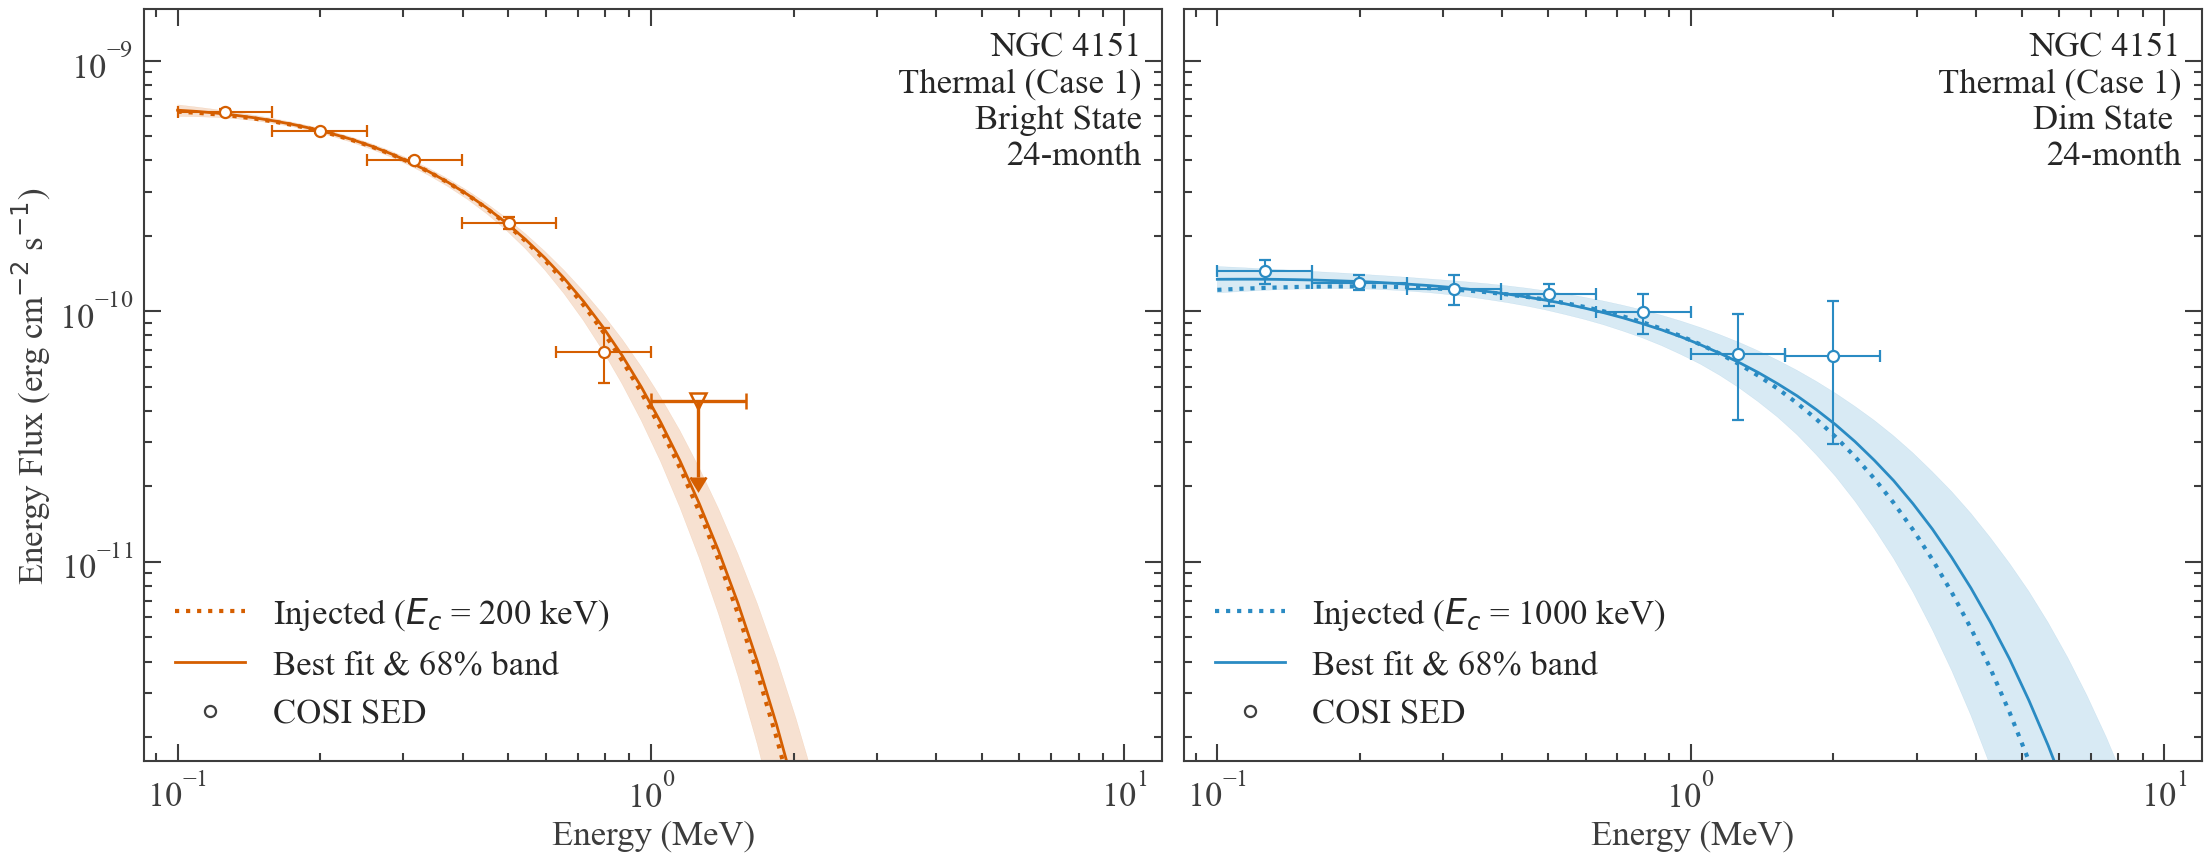

In [54]:
from agn_sed_ensemble import classify_representative_sed

# Plot A uses only the selected representative realization. Its own
# per-bin TS decides detection/upper limit/omission; no 300-seed
# bin-median statistic enters this plot.
representative_thermal_cosi_sed_df_ec1000 = classify_representative_sed(thermal_cosi_sed_df_ec1000, detection_ts=4.0)
representative_thermal_cosi_sed_df = classify_representative_sed(thermal_cosi_sed_df, detection_ts=4.0)

print('Plot A: representative median data set; classification uses its own bin TS.')
n_sed_bins_200 = len(representative_thermal_cosi_sed_df)
det_200, ul_200 = _split_sed_detections(representative_thermal_cosi_sed_df)

fig, axes = plt.subplots(1, 2, figsize=(22, 8.5), sharex=True, sharey=True, constrained_layout=True)
ax = axes[0]
_style_sed_axis(ax)

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj,
    color='#D55E00',
    ls=':',
    lw=3,
    label='Injected thermal model (Bright State)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median,
    color='#D55E00',
    lw=2,
    label='Global COSI-only fit (Bright State)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo,
    SED_KEV_TO_ERG * energy * energy * flux_hi,
    alpha=0.18,
    color='#D55E00',
)

if not det_200.empty:
    detection_xerr_200 = _make_xerr(det_200)
    detection_yerr_200 = np.vstack(
        [
            np.maximum(det_200['sed_erg_cm2_s'] - det_200['sed_lo_erg_cm2_s'], 0),
            np.maximum(det_200['sed_hi_erg_cm2_s'] - det_200['sed_erg_cm2_s'], 0),
        ]
    )

    ax.errorbar(
        det_200['e_ref_keV'] * KEV_TO_MEV,
        det_200['sed_erg_cm2_s'],
        xerr=detection_xerr_200,
        yerr=detection_yerr_200,
        fmt='o',
        color='#D55E00',
        ecolor='#D55E00',
        markerfacecolor='white',
        markeredgecolor='#D55E00',
        markeredgewidth=1.6,
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label=f'Bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_200)} detections out of {n_sed_bins_200} bins)',
    )

if not ul_200.empty:
    upper_xerr_200 = _make_xerr(ul_200)
    upper_y_200 = ul_200['sed_hi_erg_cm2_s'].to_numpy()
    upper_yerr_200 = np.maximum(0.5 * upper_y_200, np.finfo(float).tiny)

    ax.errorbar(
        ul_200['e_ref_keV'] * KEV_TO_MEV,
        upper_y_200,
        xerr=upper_xerr_200,
        yerr=upper_yerr_200,
        uplims=True,
        fmt='v',
        color='#D55E00',
        ecolor='#D55E00',
        markerfacecolor='white',
        markeredgecolor='#D55E00',
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label='_nolegend_',
    )

legend_handles = [
    plt.Line2D([], [], color='#D55E00', ls=':', lw=3, label='Injected ($E_{c}$ = 200 keV)'),
    plt.Line2D([], [], color='#D55E00', lw=2, label='Best fit & 68% band'),
]

if not det_200.empty:
    legend_handles.append(
        plt.Line2D([], [], color='0.25', marker='o', markerfacecolor='white', markeredgewidth=1.6, linestyle='None', markersize=8, label='COSI SED')
    )

ax.text(
    0.98, 0.97,
    f'NGC 4151\nThermal (Case 1)\nBright State\n{exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

n_sed_bins_1000 = len(representative_thermal_cosi_sed_df_ec1000)
det_1000, ul_1000 = _split_sed_detections(representative_thermal_cosi_sed_df_ec1000)

ax = axes[1]
_style_sed_axis(ax)
ax.set_ylabel('')

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj_ec1000,
    color='#2A8BC3',
    ls=':',
    lw=3,
    label='Injected thermal model (Dim State)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median_ec1000,
    color='#2A8BC3',
    lw=2,
    label='Global COSI-only fit (Dim State)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo_ec1000,
    SED_KEV_TO_ERG * energy * energy * flux_hi_ec1000,
    alpha=0.18,
    color='#2A8BC3',
)

if not det_1000.empty:
    detection_xerr_1000 = _make_xerr(det_1000)
    detection_yerr_1000 = np.vstack(
        [
            np.maximum(det_1000['sed_erg_cm2_s'] - det_1000['sed_lo_erg_cm2_s'], 0),
            np.maximum(det_1000['sed_hi_erg_cm2_s'] - det_1000['sed_erg_cm2_s'], 0),
        ]
    )

    ax.errorbar(
        det_1000['e_ref_keV'] * KEV_TO_MEV,
        det_1000['sed_erg_cm2_s'],
        xerr=detection_xerr_1000,
        yerr=detection_yerr_1000,
        fmt='o',
        color='#2A8BC3',
        ecolor='#2A8BC3',
        markerfacecolor='white',
        markeredgecolor='#2A8BC3',
        markeredgewidth=1.6,
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label=f'Bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_1000)} detections out of {n_sed_bins_1000} bins)',
    )

if not ul_1000.empty:
    upper_xerr_1000 = _make_xerr(ul_1000)
    upper_y_1000 = ul_1000['sed_hi_erg_cm2_s'].to_numpy()
    upper_yerr_1000 = np.maximum(0.5 * upper_y_1000, np.finfo(float).tiny)

    ax.errorbar(
        ul_1000['e_ref_keV'] * KEV_TO_MEV,
        upper_y_1000,
        xerr=upper_xerr_1000,
        yerr=upper_yerr_1000,
        uplims=True,
        fmt='v',
        color='#2A8BC3',
        ecolor='#2A8BC3',
        markerfacecolor='white',
        markeredgecolor='#2A8BC3',
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label='_nolegend_',
    )

legend_handles = [
    plt.Line2D([], [], color='#2A8BC3', ls=':', lw=3, label='Injected ($E_{c}$ = 1000 keV)'),
    plt.Line2D([], [], color='#2A8BC3', lw=2, label='Best fit & 68% band'),
]

if not det_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color='0.25', marker='o', markerfacecolor='white', markeredgewidth=1.6, linestyle='None', markersize=8, label='COSI SED')
    )

ax.text(
    0.98, 0.97,
    f'NGC 4151\nThermal (Case 1)\nDim State \n{exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

save_path = f'/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_Cpl_Dim_Bright_200_1000_{exposure_4151}Months_SED_RepresentativeMedianDataset.pdf'
fig.savefig(save_path, bbox_inches='tight')
display(fig)


### Plot B — 300-seed median SED

SED bin values and point/upper-limit decisions come from the 300-seed bin-by-bin ensemble medians.


In [55]:
from agn_sed_ensemble import (
    ensemble_summary_to_sed_dataframe,
    run_or_load_manifest_sed_ensemble,
)

SED_ENSEMBLE_RECOMPUTE = False
SED_ENSEMBLE_PSEUDOCOUNT = BACKGROUND_PSEUDOCOUNT

_, bright_sed_summary, _, bright_sed_summary_file = run_or_load_manifest_sed_ensemble(
    manifest=bright_manifest, source_expectation=NGC4151_ec200,
    background_expectation=bkg, injected_shape=spectrum_inj_ec200,
    n_sed_bins=len(thermal_cosi_sed_df), background_pseudocount=SED_ENSEMBLE_PSEUDOCOUNT,
    recompute=SED_ENSEMBLE_RECOMPUTE,
)
_, dim_sed_summary, _, dim_sed_summary_file = run_or_load_manifest_sed_ensemble(
    manifest=dim_manifest, source_expectation=NGC4151_ec1000,
    background_expectation=bkg, injected_shape=spectrum_inj_ec1000,
    n_sed_bins=len(thermal_cosi_sed_df_ec1000), background_pseudocount=SED_ENSEMBLE_PSEUDOCOUNT,
    recompute=SED_ENSEMBLE_RECOMPUTE,
)
ensemble_thermal_cosi_sed_df = ensemble_summary_to_sed_dataframe(bright_sed_summary)
ensemble_thermal_cosi_sed_df_ec1000 = ensemble_summary_to_sed_dataframe(dim_sed_summary)
display(bright_sed_summary[['bin_index', 'ts_median', 'source_scale_q16', 'plot_role']])
display(dim_sed_summary[['bin_index', 'ts_median', 'source_scale_q16', 'plot_role']])


,bin_index,ts_median,source_scale_q16,plot_role
0,1,2191.503555,0.973010,detection
1,2,3250.896882,0.983967,detection
2,3,2183.008188,0.977304,detection
3,4,474.879185,0.951146,detection
4,5,56.881603,0.811776,detection
5,6,0.337599,0.000000,upper_limit
6,7,0.000000,0.000000,omitted
7,8,0.000000,0.000000,omitted


,bin_index,ts_median,source_scale_q16,plot_role
0,1,237.737602,0.882701,detection
1,2,240.038275,0.929781,detection
2,3,334.843364,0.929734,detection
3,4,162.418287,0.902524,detection
4,5,68.181543,0.809593,detection
5,6,7.968651,0.507514,detection
6,7,0.930947,0.000000,upper_limit
7,8,0.000000,0.000000,omitted
8,9,0.000000,0.000000,omitted
9,10,0.000000,0.000000,omitted


Plot B: 300-seed ensemble median SED; classification uses median bin TS.


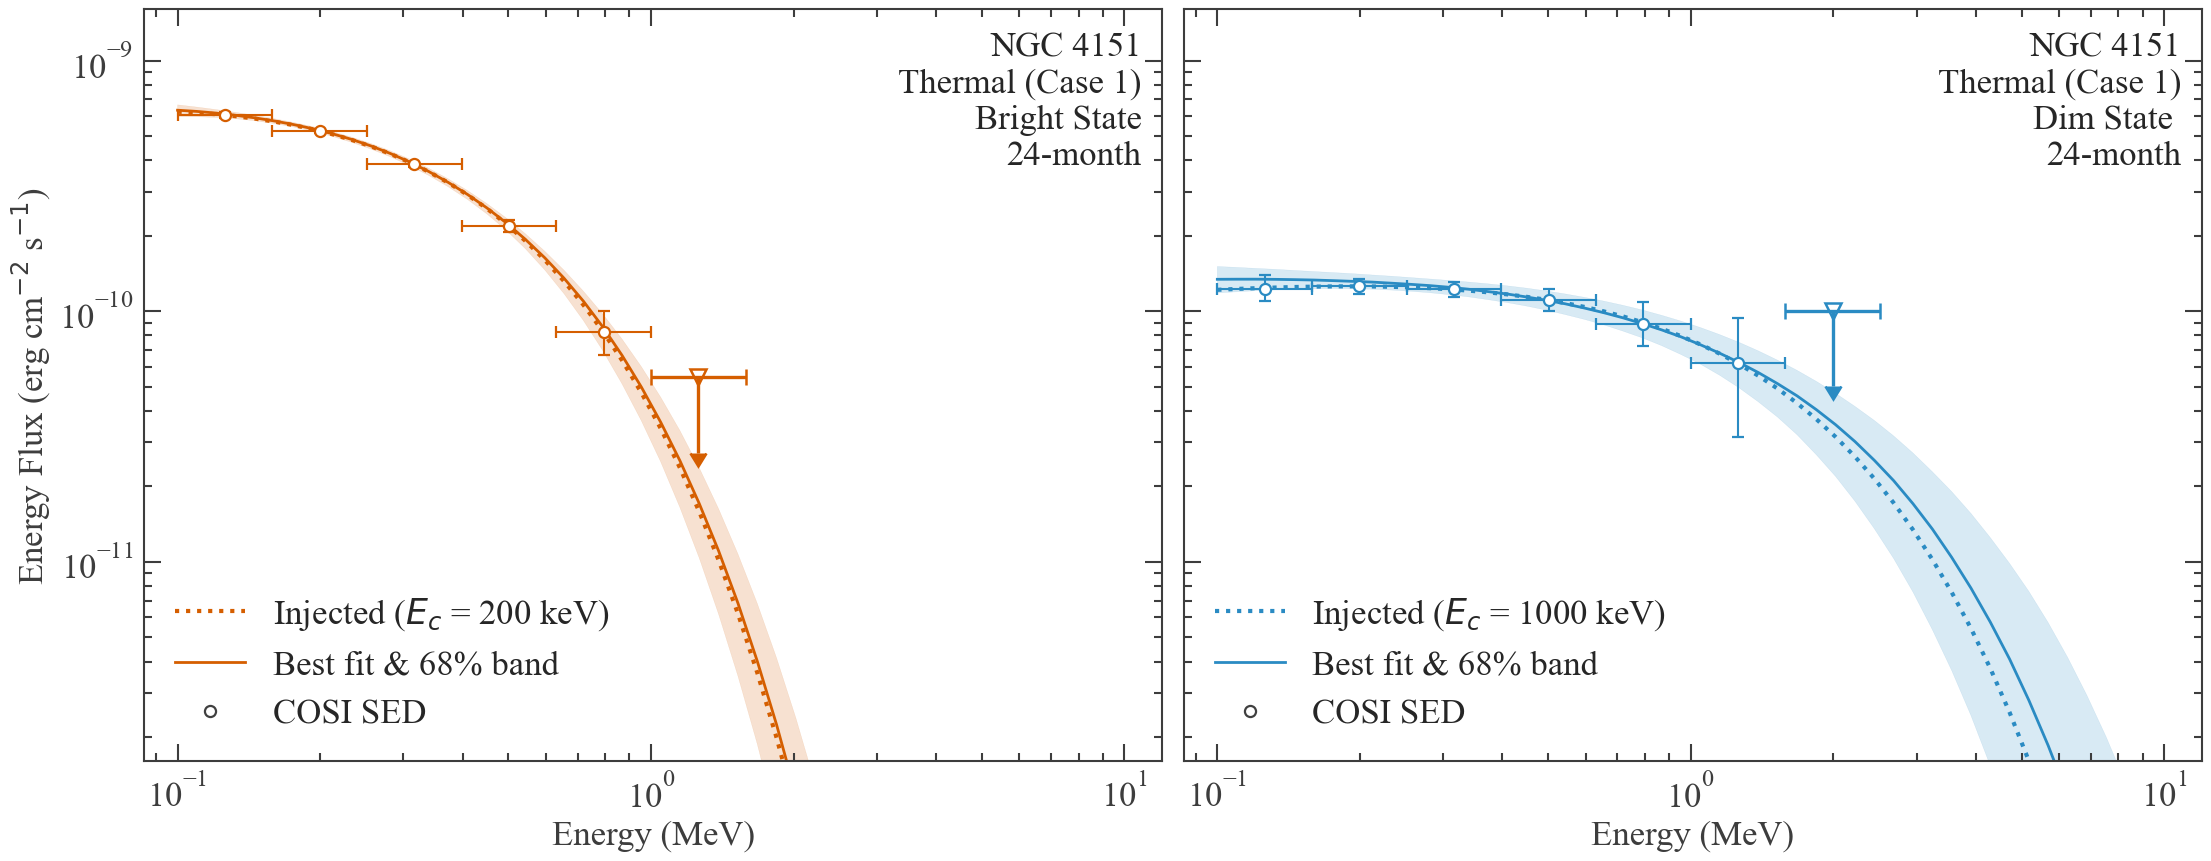

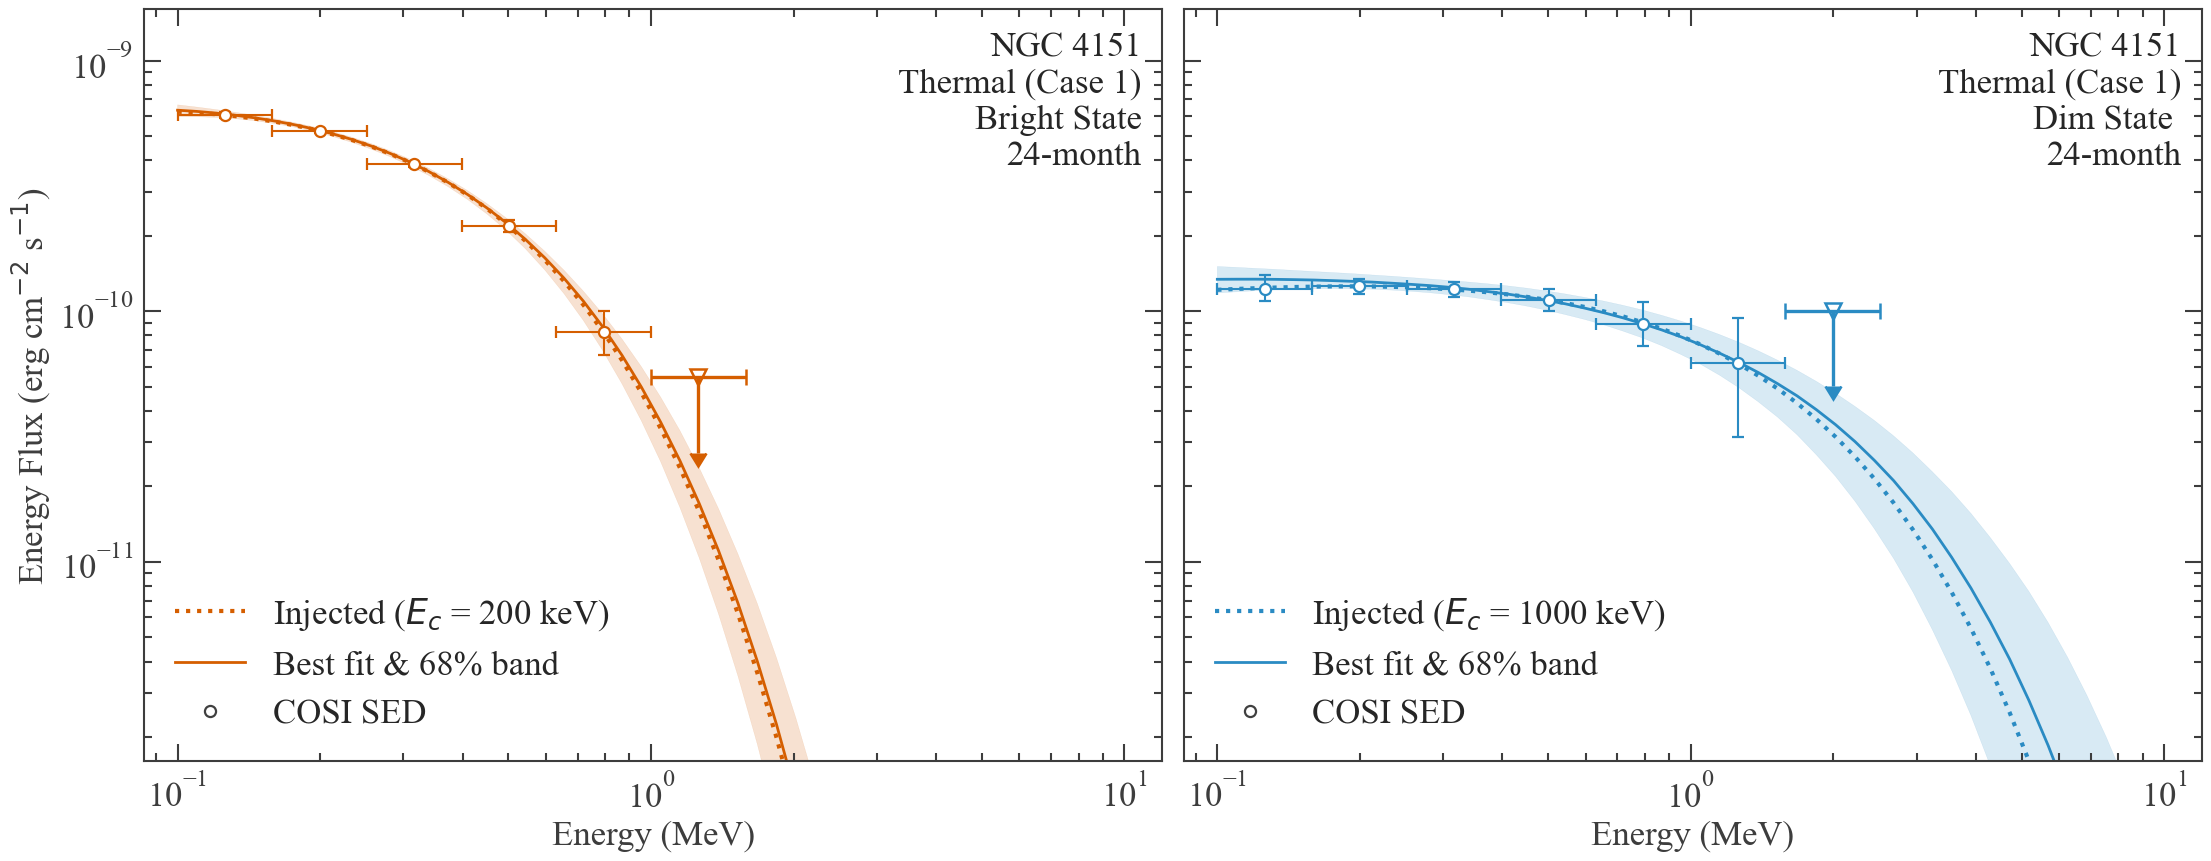

In [56]:
# Plot B uses the bin-by-bin median flux and median TS from all 300 seeds.
print('Plot B: 300-seed ensemble median SED; classification uses median bin TS.')

n_sed_bins_200 = len(ensemble_thermal_cosi_sed_df)
det_200, ul_200 = _split_sed_detections(ensemble_thermal_cosi_sed_df)

fig, axes = plt.subplots(1, 2, figsize=(22, 8.5), sharex=True, sharey=True, constrained_layout=True)
ax = axes[0]
_style_sed_axis(ax)

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj,
    color='#D55E00',
    ls=':',
    lw=3,
    label='Injected thermal model (Bright State)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median,
    color='#D55E00',
    lw=2,
    label='Global COSI-only fit (Bright State)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo,
    SED_KEV_TO_ERG * energy * energy * flux_hi,
    alpha=0.18,
    color='#D55E00',
)

if not det_200.empty:
    detection_xerr_200 = _make_xerr(det_200)
    detection_yerr_200 = np.vstack(
        [
            np.maximum(det_200['sed_erg_cm2_s'] - det_200['sed_lo_erg_cm2_s'], 0),
            np.maximum(det_200['sed_hi_erg_cm2_s'] - det_200['sed_erg_cm2_s'], 0),
        ]
    )

    ax.errorbar(
        det_200['e_ref_keV'] * KEV_TO_MEV,
        det_200['sed_erg_cm2_s'],
        xerr=detection_xerr_200,
        yerr=detection_yerr_200,
        fmt='o',
        color='#D55E00',
        ecolor='#D55E00',
        markerfacecolor='white',
        markeredgecolor='#D55E00',
        markeredgewidth=1.6,
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label=f'Bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_200)} detections out of {n_sed_bins_200} bins)',
    )

if not ul_200.empty:
    upper_xerr_200 = _make_xerr(ul_200)
    upper_y_200 = ul_200['sed_hi_erg_cm2_s'].to_numpy()
    upper_yerr_200 = np.maximum(0.5 * upper_y_200, np.finfo(float).tiny)

    ax.errorbar(
        ul_200['e_ref_keV'] * KEV_TO_MEV,
        upper_y_200,
        xerr=upper_xerr_200,
        yerr=upper_yerr_200,
        uplims=True,
        fmt='v',
        color='#D55E00',
        ecolor='#D55E00',
        markerfacecolor='white',
        markeredgecolor='#D55E00',
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label='_nolegend_',
    )

legend_handles = [
    plt.Line2D([], [], color='#D55E00', ls=':', lw=3, label='Injected ($E_{c}$ = 200 keV)'),
    plt.Line2D([], [], color='#D55E00', lw=2, label='Best fit & 68% band'),
]

if not det_200.empty:
    legend_handles.append(
        plt.Line2D([], [], color='0.25', marker='o', markerfacecolor='white', markeredgewidth=1.6, linestyle='None', markersize=8, label='COSI SED')
    )

ax.text(
    0.98, 0.97,
    f'NGC 4151\nThermal (Case 1)\nBright State\n{exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

n_sed_bins_1000 = len(ensemble_thermal_cosi_sed_df_ec1000)
det_1000, ul_1000 = _split_sed_detections(ensemble_thermal_cosi_sed_df_ec1000)

ax = axes[1]
_style_sed_axis(ax)
ax.set_ylabel('')

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj_ec1000,
    color='#2A8BC3',
    ls=':',
    lw=3,
    label='Injected thermal model (Dim State)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median_ec1000,
    color='#2A8BC3',
    lw=2,
    label='Global COSI-only fit (Dim State)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo_ec1000,
    SED_KEV_TO_ERG * energy * energy * flux_hi_ec1000,
    alpha=0.18,
    color='#2A8BC3',
)

if not det_1000.empty:
    detection_xerr_1000 = _make_xerr(det_1000)
    detection_yerr_1000 = np.vstack(
        [
            np.maximum(det_1000['sed_erg_cm2_s'] - det_1000['sed_lo_erg_cm2_s'], 0),
            np.maximum(det_1000['sed_hi_erg_cm2_s'] - det_1000['sed_erg_cm2_s'], 0),
        ]
    )

    ax.errorbar(
        det_1000['e_ref_keV'] * KEV_TO_MEV,
        det_1000['sed_erg_cm2_s'],
        xerr=detection_xerr_1000,
        yerr=detection_yerr_1000,
        fmt='o',
        color='#2A8BC3',
        ecolor='#2A8BC3',
        markerfacecolor='white',
        markeredgecolor='#2A8BC3',
        markeredgewidth=1.6,
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label=f'Bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_1000)} detections out of {n_sed_bins_1000} bins)',
    )

if not ul_1000.empty:
    upper_xerr_1000 = _make_xerr(ul_1000)
    upper_y_1000 = ul_1000['sed_hi_erg_cm2_s'].to_numpy()
    upper_yerr_1000 = np.maximum(0.5 * upper_y_1000, np.finfo(float).tiny)

    ax.errorbar(
        ul_1000['e_ref_keV'] * KEV_TO_MEV,
        upper_y_1000,
        xerr=upper_xerr_1000,
        yerr=upper_yerr_1000,
        uplims=True,
        fmt='v',
        color='#2A8BC3',
        ecolor='#2A8BC3',
        markerfacecolor='white',
        markeredgecolor='#2A8BC3',
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label='_nolegend_',
    )

legend_handles = [
    plt.Line2D([], [], color='#2A8BC3', ls=':', lw=3, label='Injected ($E_{c}$ = 1000 keV)'),
    plt.Line2D([], [], color='#2A8BC3', lw=2, label='Best fit & 68% band'),
]

if not det_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color='0.25', marker='o', markerfacecolor='white', markeredgewidth=1.6, linestyle='None', markersize=8, label='COSI SED')
    )

ax.text(
    0.98, 0.97,
    f'NGC 4151\nThermal (Case 1)\nDim State \n{exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

save_path = f'/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_Cpl_Dim_Bright_200_1000_{exposure_4151}Months_SED_300SeedMedianSED.pdf'
# Plot B is displayed but intentionally not saved.
display(fig)
